In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


#UNDERSTAND YOUR DATA 

In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

#Data cleaning and validation

In [4]:
df = df[df["Sales"] > 0]
df = df[df["Units"] > 0]
df.shape 

(10194, 18)

#create probablitiy metrics 

In [5]:
df["Gross Mrgin %"] = (df["Gross Profit"] / df["Sales"]) * 100
df["Profit per Unit"] = df["Gross Profit"] / df["Units"]
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Gross Mrgin %,Profit per Unit
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,64.923077,2.11
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,65.333333,2.45
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,71.346705,2.49
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,69.444444,2.50
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,65.333333,2.45


#Basic Company Overview

In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Gross Profit"].sum()
overall_margin = (total_profit / total_sales)*100

print("Toatal Sales:", total_sales)
print("Total Profit:", total_profit)
print("Overall Margin %", overall_margin)

Toatal Sales: 141783.63
Total Profit: 93442.79999999999
Overall Margin % 65.90521063679917


#Product Level Profitability

In [7]:
product_summary = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Units': 'sum'
}).reset_index()

product_summary['Gross Margin %'] = (
    product_summary['Gross Profit'] / product_summary['Sales']
) * 100

product_summary['Profit per Unit'] = (
    product_summary['Gross Profit'] / product_summary['Units']
)

product_summary.head()

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25
2,Fun Dip,12.00,4.80,8,40.000000,0.60
3,Hair Toffee,76.50,59.50,17,77.777778,3.50
4,Kazookles,1205.75,92.75,371,7.692308,0.25


#Identify top and bottom products

In [8]:
product_summary.sort_values(by="Gross Profit", ascending=False).head()

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40


In [9]:
product_summary.sort_values(by='Gross Margin %').head()

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit
4,Kazookles,1205.75,92.75,371,7.692308,0.25
2,Fun Dip,12.00,4.80,8,40.000000,0.60
7,Nerds,15.00,7.00,10,46.666667,0.70
8,SweeTARTS,61.50,28.70,41,46.666667,0.70
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00


#Division - Level Analysis

In [10]:
division_summary = df.groupby('Division').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).reset_index()

division_summary['Gross Margin %'] = (
    division_summary['Gross Profit'] / division_summary['Sales']
)

division_summary

,Division,Sales,Gross Profit,Gross Margin %
0,Chocolate,131692.90,88824.62,0.674483
1,Other,9663.25,4333.45,0.448446
2,Sugar,427.48,284.73,0.666066


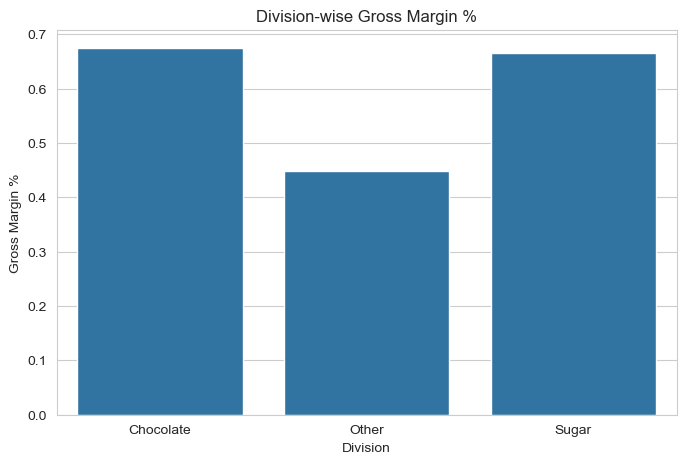

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=division_summary, x='Division', y='Gross Margin %')
plt.title("Division-wise Gross Margin %")
plt.show()

#Pareto Analysis (80/20 Rule)

In [12]:
product_summary = product_summary.sort_values(by='Gross Profit', ascending=False)

In [13]:
product_summary['Cumulative Profit %'] = (
    product_summary['Gross Profit'].cumsum() /
    product_summary['Gross Profit'].sum()
) * 100

product_summary.head(10)

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Cumulative Profit %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,40.632023
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,59.299454
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,77.299717
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,95.057747
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00,99.263528
14,Wonka Gum,597.50,310.70,478,52.000000,0.65,99.596031
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,99.707329
4,Kazookles,1205.75,92.75,371,7.692308,0.25,99.806588
3,Hair Toffee,76.50,59.50,17,77.777778,3.50,99.870263


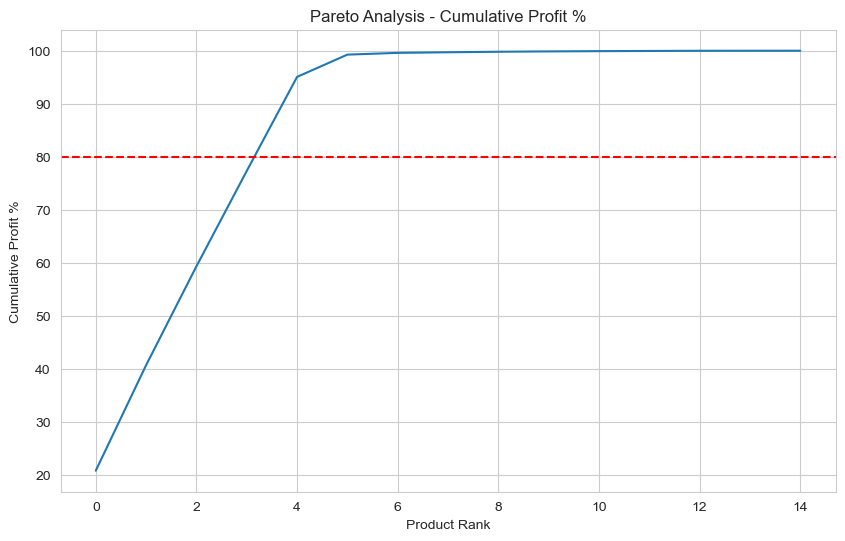

In [14]:
plt.figure(figsize=(10,6))
plt.plot(product_summary['Cumulative Profit %'].values)
plt.axhline(y=80, color='r', linestyle='--')
plt.title("Pareto Analysis - Cumulative Profit %")
plt.xlabel("Product Rank")
plt.ylabel("Cumulative Profit %")
plt.show()

In [15]:
products_80 = product_summary[product_summary['Cumulative Profit %'] <= 80]
len(products_80)

4

#Revenue vs profit imbalane

In [16]:
total_sales = product_summary['Sales'].sum()
total_profit = product_summary['Gross Profit'].sum()

product_summary['Revenue Contribution %'] = (
    product_summary['Sales'] / total_sales
) * 100

product_summary['Profit Contribution %'] = (
    product_summary['Gross Profit'] / total_profit
) * 100

product_summary.head()

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Cumulative Profit %,Revenue Contribution %,Profit Contribution %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,20.715882,19.660098,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,40.632023,20.090472,19.916141
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,59.299454,18.949825,18.667431
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,77.299717,16.627413,18.000263
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,95.057747,17.555200,17.758030


#cost vs margin diagnostic

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(df['Cost'], df['Gross Margin %'])
plt.xlabel("Cost")
plt.ylabel("Gross Margin %")
plt.title("Cost vs Margin Analysis")
plt.show()

KeyError: 'Gross Margin %'

<Figure size 800x600 with 0 Axes>

In [ ]:
df.columns

In [ ]:
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100

In [ ]:
df.head()

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Cost'], df['Gross Margin %'])
plt.xlabel("Cost")
plt.ylabel("Gross Margin %")
plt.title("Cost vs Margin Analysis")
plt.show()

#Margin Volatility Over Time (Advanced)

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_margin = df.groupby(
    df['Order Date'].dt.to_period("M")
)['Gross Margin %'].mean()

monthly_margin.plot(figsize=(10,5))
plt.title("Monthly Average Gross Margin %")
plt.show()

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [ ]:
monthly_margin = df.groupby(
    df['Order Date'].dt.to_period("M")
)['Gross Margin %'].mean()

monthly_margin.plot(figsize=(10,5))
plt.title("Monthly Average Gross Margin %")
plt.xlabel("Month")
plt.ylabel("Average Gross Margin %")
plt.show()

In [ ]:
df.groupby('Factory')['Gross Profit'].sum().sort_values(ascending=False)

#Factory level insight


In [18]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Gross Mrgin %',
       'Profit per Unit'],
      dtype='object')

In [19]:
factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

In [20]:
df['Factory'] = df['Product Name'].map(factory_mapping)

In [21]:
df[['Product Name','Factory']].head()

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [22]:
df.groupby('Factory')['Gross Profit'].sum().sort_values(ascending=False)

Factory
Lot's O' Nuts        52771.05
Wicked Choccy's      36053.57
Secret Factory        4344.70
The Other Factory      152.25
Sugar Shack            121.23
Name: Gross Profit, dtype: float64

In [23]:
factory_summary = df.groupby('Factory').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Units': 'sum'
}).reset_index()

factory_summary['Gross Margin %'] = (
    factory_summary['Gross Profit'] / factory_summary['Sales']
) * 100

factory_summary

,Factory,Sales,Gross Profit,Units,Gross Margin %
0,Lot's O' Nuts,76340.15,52771.05,21412,69.126207
1,Secret Factory,8587.50,4344.70,884,50.593304
2,Sugar Shack,220.98,121.23,107,54.860168
3,The Other Factory,1282.25,152.25,388,11.873660
4,Wicked Choccy's,55352.75,36053.57,15863,65.134198


In [24]:
factory_summary.sort_values(by='Gross Margin %', ascending=False)


,Factory,Sales,Gross Profit,Units,Gross Margin %
0,Lot's O' Nuts,76340.15,52771.05,21412,69.126207
4,Wicked Choccy's,55352.75,36053.57,15863,65.134198
2,Sugar Shack,220.98,121.23,107,54.860168
1,Secret Factory,8587.50,4344.70,884,50.593304
3,The Other Factory,1282.25,152.25,388,11.873660


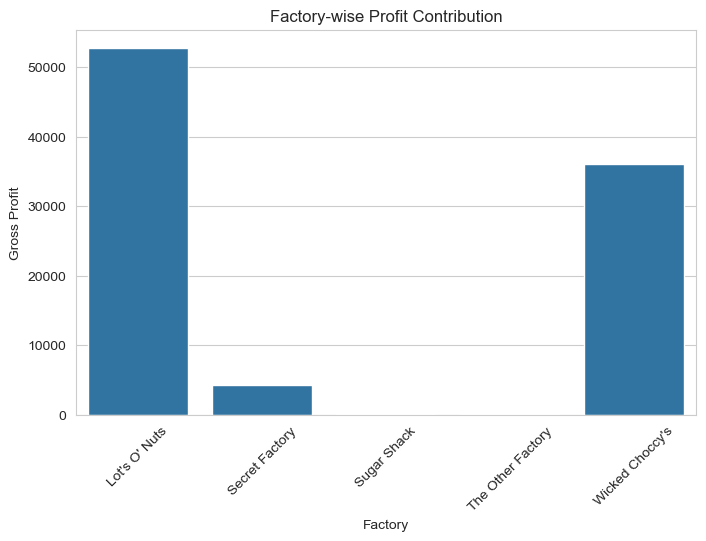

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=factory_summary, x='Factory', y='Gross Profit')
plt.title("Factory-wise Profit Contribution")
plt.xticks(rotation=45)
plt.show()

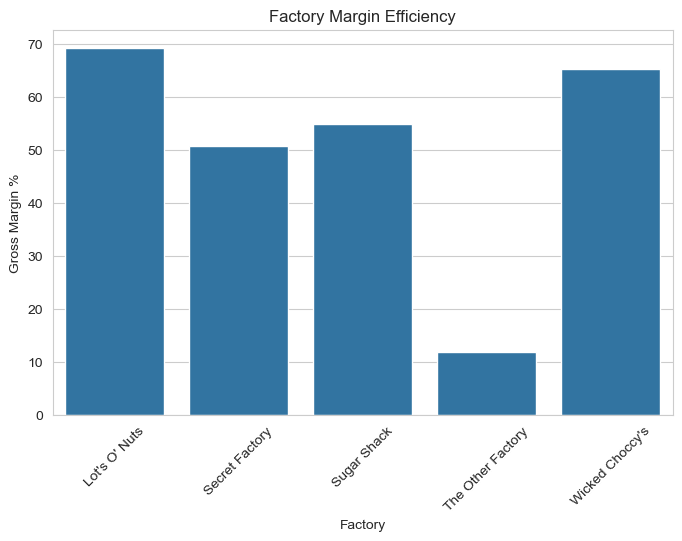

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(data=factory_summary, x='Factory', y='Gross Margin %')
plt.title("Factory Margin Efficiency")
plt.xticks(rotation=45)
plt.show()

##Region probablity analysis

In [27]:
region_summary = df.groupby('Region').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Units': 'sum'
}).reset_index()

region_summary['Gross Margin %'] = (
    region_summary['Gross Profit'] / region_summary['Sales']
) * 100

region_summary

,Region,Sales,Gross Profit,Units,Gross Margin %
0,Atlantic,41197.24,26973.70,11159,65.474532
1,Gulf,22247.26,14700.67,6209,66.078564
2,Interior,32037.60,21282.49,8820,66.429726
3,Pacific,46301.53,30485.94,12466,65.842187


In [28]:
region_summary.sort_values(by='Gross Profit', ascending=False)

,Region,Sales,Gross Profit,Units,Gross Margin %
3,Pacific,46301.53,30485.94,12466,65.842187
0,Atlantic,41197.24,26973.70,11159,65.474532
2,Interior,32037.60,21282.49,8820,66.429726
1,Gulf,22247.26,14700.67,6209,66.078564


In [29]:
region_summary.sort_values(by='Gross Margin %', ascending=False)

,Region,Sales,Gross Profit,Units,Gross Margin %
2,Interior,32037.60,21282.49,8820,66.429726
1,Gulf,22247.26,14700.67,6209,66.078564
3,Pacific,46301.53,30485.94,12466,65.842187
0,Atlantic,41197.24,26973.70,11159,65.474532


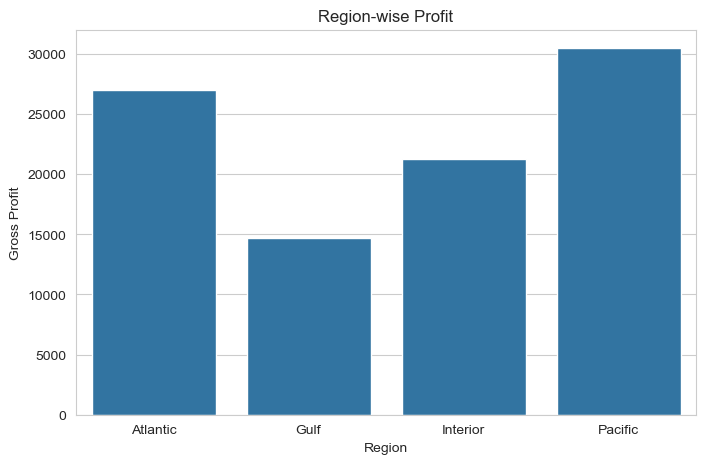

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=region_summary, x='Region', y='Gross Profit')
plt.title("Region-wise Profit")
plt.show()

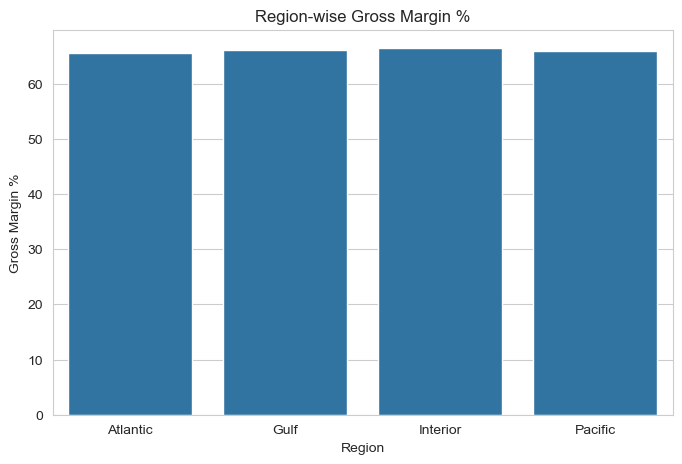

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_summary, x='Region', y='Gross Margin %')
plt.title("Region-wise Gross Margin %")
plt.show()

##Pareto Analysis (80/20 Rule)

This will help answer:

Which small number of products generate most of the company’s profit?

Many companies discover that 20% of products generate 80% of profit.

#sort product by profit

In [32]:
product_summary = product_summary.sort_values(by='Gross Profit', ascending=False)
product_summary.head()

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Cumulative Profit %,Revenue Contribution %,Profit Contribution %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,20.715882,19.660098,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,40.632023,20.090472,19.916141
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,59.299454,18.949825,18.667431
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,77.299717,16.627413,18.000263
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,95.057747,17.555200,17.758030


#calculate cumulative profit

In [33]:
product_summary['Cumulative Profit'] = product_summary['Gross Profit'].cumsum()

product_summary['Cumulative Profit %'] = (
    product_summary['Cumulative Profit'] /
    product_summary['Gross Profit'].sum()
) * 100

product_summary.head()

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Cumulative Profit %,Revenue Contribution %,Profit Contribution %,Cumulative Profit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,20.715882,19.660098,20.715882,19357.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,40.632023,20.090472,19.916141,37967.70
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,59.299454,18.949825,18.667431,55411.07
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,77.299717,16.627413,18.000263,72231.02
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,95.057747,17.555200,17.758030,88824.62


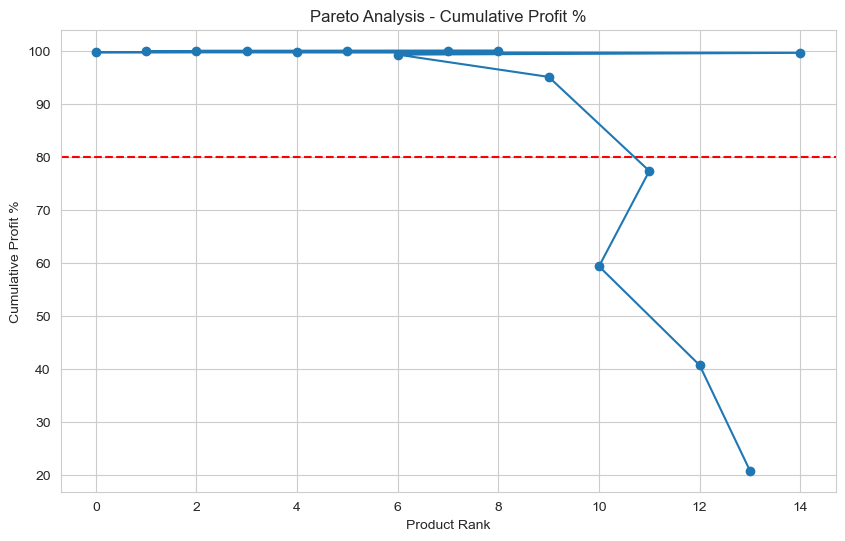

In [34]:
plt.figure(figsize=(10,6))

plt.plot(product_summary['Cumulative Profit %'], marker='o')
plt.axhline(y=80, color='red', linestyle='--')

plt.title("Pareto Analysis - Cumulative Profit %")
plt.xlabel("Product Rank")
plt.ylabel("Cumulative Profit %")

plt.show()

#red line shows 80% of profit 

##counting products generating 80% profit 

In [35]:
top_products = product_summary[product_summary['Cumulative Profit %'] <= 80]

len(top_products)

4

##Next we will do Cost vs Margin Diagnostic Analysis.

This identifies:

Products that are too expensive to produce

Products with poor pricing strategy

Products that might need cost reduction or discontinuation

#cost vs sales scatter plot

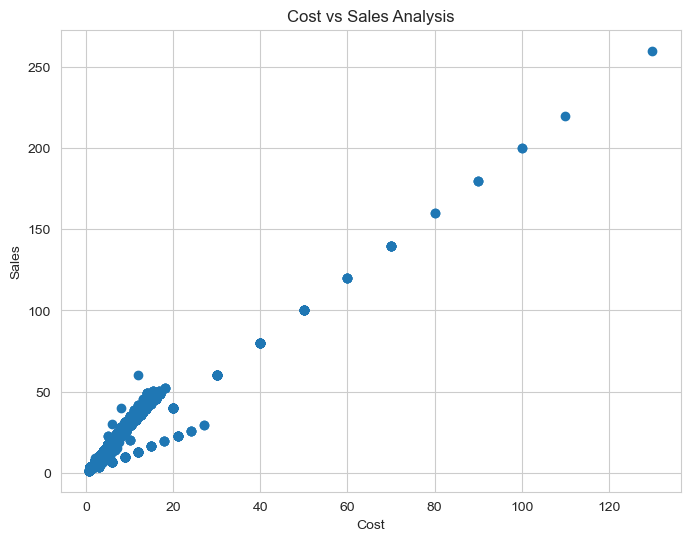

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(df['Cost'], df['Sales'])

plt.xlabel("Cost")
plt.ylabel("Sales")
plt.title("Cost vs Sales Analysis")

plt.show()

#Cost vs margin analysis

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(df['Cost'], df['Gross Margin %'])

plt.xlabel("Cost")
plt.ylabel("Gross Margin %")
plt.title("Cost vs Margin Diagnostics")

plt.show()

KeyError: 'Gross Margin %'

<Figure size 800x600 with 0 Axes>

In [38]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Gross Mrgin %',
       'Profit per Unit', 'Factory'],
      dtype='object')

In [39]:
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100

In [40]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Gross Mrgin %,Profit per Unit,Factory,Gross Margin %
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,...,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,64.923077,2.11,Wicked Choccy's,64.923077
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,65.333333,2.45,Wicked Choccy's,65.333333
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,71.346705,2.49,Lot's O' Nuts,71.346705
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,69.444444,2.50,Lot's O' Nuts,69.444444
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,65.333333,2.45,Wicked Choccy's,65.333333


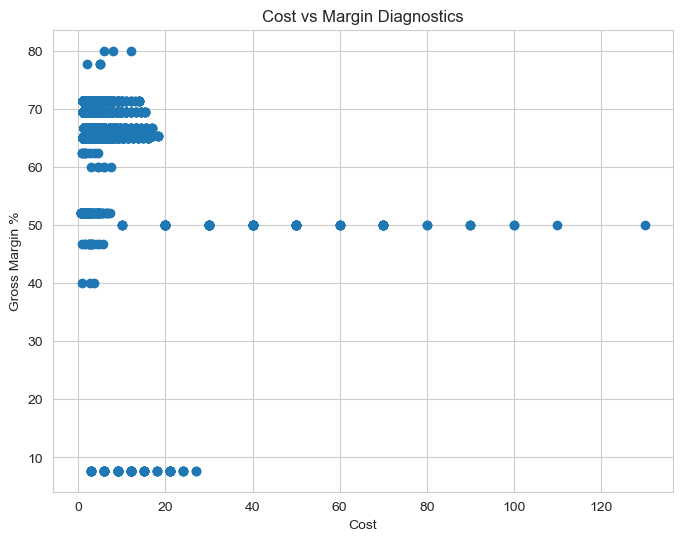

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(df['Cost'], df['Gross Margin %'])

plt.xlabel("Cost")
plt.ylabel("Gross Margin %")
plt.title("Cost vs Margin Diagnostics")

plt.show()

#Identify Cost-Heavy Low Margin Products

In [42]:
product_summary.sort_values(by='Gross Margin %').head(10)

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Cumulative Profit %,Revenue Contribution %,Profit Contribution %,Cumulative Profit
4,Kazookles,1205.75,92.75,371,7.692308,0.25,99.806588,0.850416,0.099259,93262.07
2,Fun Dip,12.00,4.80,8,40.000000,0.60,100.000000,0.008464,0.005137,93442.80
8,SweeTARTS,61.50,28.70,41,46.666667,0.70,99.987372,0.043376,0.030714,93431.00
7,Nerds,15.00,7.00,10,46.666667,0.70,99.994863,0.010580,0.007491,93438.00
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00,99.263528,5.543658,4.205782,92754.62
14,Wonka Gum,597.50,310.70,478,52.000000,0.65,99.596031,0.421417,0.332503,93065.32
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25,99.920829,0.055542,0.050566,93368.82
5,Laffy Taffy,53.73,33.48,27,62.311558,1.24,99.956658,0.037896,0.035829,93402.30
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,59.299454,18.949825,18.667431,55411.07
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,40.632023,20.090472,19.916141,37967.70


#identify best products

In [43]:
product_summary.sort_values(by='Gross Margin %', ascending=False).head(10)

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Cumulative Profit %,Revenue Contribution %,Profit Contribution %,Cumulative Profit
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,99.707329,0.091689,0.111298,93169.32
3,Hair Toffee,76.50,59.50,17,77.777778,3.50,99.870263,0.053955,0.063675,93321.57
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,77.299717,16.627413,18.000263,72231.02
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,20.715882,19.660098,20.715882,19357.50
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,95.057747,17.555200,17.758030,88824.62
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,40.632023,20.090472,19.916141,37967.70
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,59.299454,18.949825,18.667431,55411.07
5,Laffy Taffy,53.73,33.48,27,62.311558,1.24,99.956658,0.037896,0.035829,93402.30
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25,99.920829,0.055542,0.050566,93368.82
14,Wonka Gum,597.50,310.70,478,52.000000,0.65,99.596031,0.421417,0.332503,93065.32


In [44]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [45]:
app.py

NameError: name 'app' is not defined

In [47]:
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------
# PAGE SETTINGS
# ------------------------------------------------

st.set_page_config(
    page_title="Nassau Candy Analytics Dashboard",
    layout="wide"
)

# ------------------------------------------------
# STYLE (FIXED TEXT COLORS)
# ------------------------------------------------

st.markdown("""
<style>

.stApp {
    background: linear-gradient(to right,#0f2027,#203a43,#2c5364);
}

/* Title */
h1 {
    color:#FFD700;
    text-align:center;
}

/* Section headings */
h2, h3 {
    color:#00FFFF;
}

/* Normal text */
p, span, label, div {
    color:white !important;
}

/* Sidebar */
section[data-testid="stSidebar"] * {
    color:black !important;
}

/* KPI cards */
[data-testid="stMetric"] {
    background-color:#1c3b57;
    padding:15px;
    border-radius:12px;
    text-align:center;
}

[data-testid="stMetricLabel"] {
    color:white !important;
}

[data-testid="stMetricValue"] {
    color:#FFD700 !important;
    font-size:26px;
}

</style>
""", unsafe_allow_html=True)

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

df = pd.read_csv("Nassau Candy Distributor.csv")

df["Gross Margin %"] = (df["Gross Profit"] / df["Sales"]) * 100
df["Profit per Unit"] = df["Gross Profit"] / df["Units"]

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")

# ------------------------------------------------
# SIDEBAR FILTERS
# ------------------------------------------------

st.sidebar.title("Dashboard Filters")

division_filter = st.sidebar.multiselect(
    "Select Division",
    df["Division"].unique(),
    default=df["Division"].unique()
)

region_filter = st.sidebar.multiselect(
    "Select Region",
    df["Region"].unique(),
    default=df["Region"].unique()
)

df = df[
    (df["Division"].isin(division_filter)) &
    (df["Region"].isin(region_filter))
]

# ------------------------------------------------
# TITLE
# ------------------------------------------------

st.title("🍬 Nassau Candy Distributor Profitability Dashboard")

# ------------------------------------------------
# KPI METRICS
# ------------------------------------------------

col1,col2,col3,col4 = st.columns(4)

col1.metric("Total Sales",f"₹{df['Sales'].sum():,.0f}")
col2.metric("Total Profit",f"₹{df['Gross Profit'].sum():,.0f}")
col3.metric("Average Margin",f"{df['Gross Margin %'].mean():.2f}%")
col4.metric("Total Units Sold",f"{df['Units'].sum():,.0f}")

st.markdown("---")

# =================================================
# ROW 1
# =================================================

col1,col2 = st.columns(2)

# Division Profitability

with col1:

    st.subheader("Division Profitability")

    division_summary = df.groupby("Division").agg({
        "Sales":"sum",
        "Gross Profit":"sum"
    }).reset_index()

    division_summary["Gross Margin %"] = (
        division_summary["Gross Profit"] /
        division_summary["Sales"]
    )*100

    fig,ax = plt.subplots(figsize=(5,4))

    sns.barplot(
        data=division_summary,
        x="Division",
        y="Gross Margin %",
        palette="viridis",
        ax=ax
    )

    ax.tick_params(colors="white")
    ax.set_xlabel("Division",color="white")
    ax.set_ylabel("Margin %",color="white")

    st.pyplot(fig)

# Regional Profitability

with col2:

    st.subheader("Regional Profitability")

    region_summary = df.groupby("Region")["Gross Profit"].sum().reset_index()

    fig,ax = plt.subplots(figsize=(5,4))

    sns.barplot(
        data=region_summary,
        x="Region",
        y="Gross Profit",
        palette="magma",
        ax=ax
    )

    ax.tick_params(colors="white")
    ax.set_xlabel("Region",color="white")
    ax.set_ylabel("Profit",color="white")

    st.pyplot(fig)

st.markdown("---")

# =================================================
# ROW 2
# =================================================

col3,col4 = st.columns(2)

# Monthly Profit Trend

with col3:

    st.subheader("Monthly Profit Trend")

    monthly_profit = df.groupby(
        df["Order Date"].dt.to_period("M")
    )["Gross Profit"].sum()

    fig,ax = plt.subplots(figsize=(5,4))

    monthly_profit.plot(marker="o",ax=ax)

    ax.tick_params(colors="white")
    ax.set_ylabel("Profit",color="white")

    st.pyplot(fig)

# Profit Contribution

with col4:

    st.subheader("Profit Contribution by Division")

    profit_share = df.groupby("Division")["Gross Profit"].sum()

    fig,ax = plt.subplots(figsize=(5,4))

    ax.pie(
        profit_share,
        labels=profit_share.index,
        autopct="%1.1f%%",
        wedgeprops={"width":0.4}
    )

    st.pyplot(fig)

st.markdown("---")

# =================================================
# ROW 3
# =================================================

col5,col6 = st.columns(2)

# Top Products

with col5:

    st.subheader("Top 10 Profitable Products")

    product_summary = df.groupby("Product Name").agg({
        "Sales":"sum",
        "Gross Profit":"sum"
    }).reset_index()

    top_products = product_summary.sort_values(
        by="Gross Profit",
        ascending=False
    ).head(10)

    st.dataframe(top_products,use_container_width=True)

# Cost vs Margin

with col6:

    st.subheader("Cost vs Margin Analysis")

    fig,ax = plt.subplots(figsize=(5,4))

    sns.scatterplot(
        data=df,
        x="Cost",
        y="Gross Margin %",
        hue="Division",
        palette="bright",
        s=90,
        ax=ax
    )

    ax.tick_params(colors="white")
    ax.set_xlabel("Cost",color="white")
    ax.set_ylabel("Margin %",color="white")

    st.pyplot(fig)

st.markdown("---")

# =================================================
# ROW 4
# =================================================

st.subheader("Pareto Profit Analysis")

product_summary = product_summary.sort_values(
    by="Gross Profit",
    ascending=False
)

product_summary["Cumulative Profit %"] = (
    product_summary["Gross Profit"].cumsum() /
    product_summary["Gross Profit"].sum()
)*100

fig,ax = plt.subplots(figsize=(10,4))

ax.plot(product_summary["Cumulative Profit %"],marker="o")
ax.axhline(80,color="red",linestyle="--")

ax.tick_params(colors="white")
ax.set_ylabel("Cumulative Profit %",color="white")
ax.set_xlabel("Product Rank",color="white")

st.pyplot(fig)

2026-03-13 18:08:36.567 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 18:08:36.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 18:08:36.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 18:08:36.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 18:08:36.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 18:08:36.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 18:08:36.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 18:08:36.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

**Import Ml Libraries**

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

**Encode Categorical Columns**

In [49]:
le_div = LabelEncoder()
le_reg = LabelEncoder()

df['Division_enc'] = le_div.fit_transform(df['Division'])
df['Region_enc'] = le_reg.fit_transform(df['Region'])

**Define Features and Trget**

In [52]:
X = df[['Sales','Cost','Units','Division_enc','Region_enc']]

y = df['Gross Profit']

**Split Dataset**

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Train Model**

In [54]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Predict**

In [55]:
y_pred = model.predict(X_test)

**Evaluate Model**

In [56]:
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("R2 Score:", r2)

Mean Absolute Error: 3.5253310814937824e-14
R2 Score: 1.0


**Plot Result**

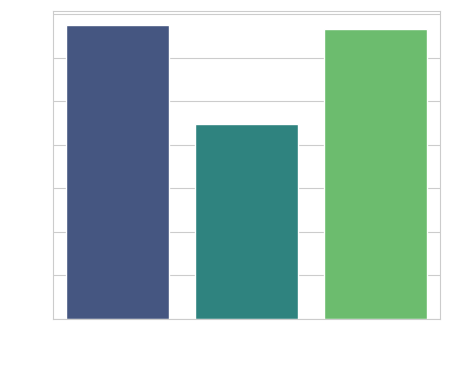

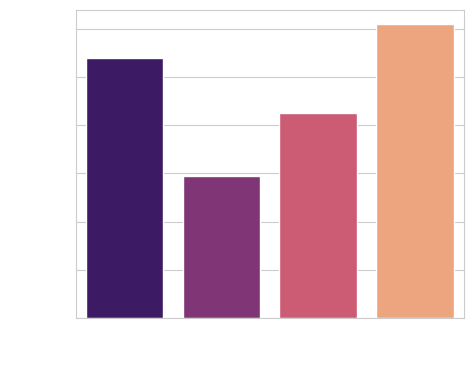

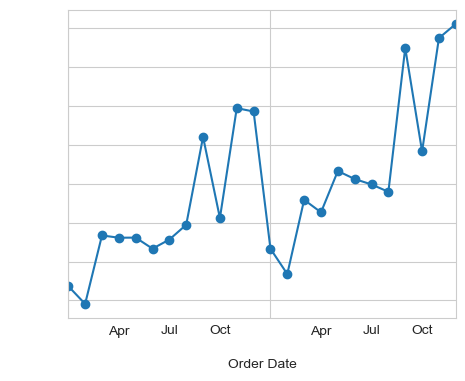

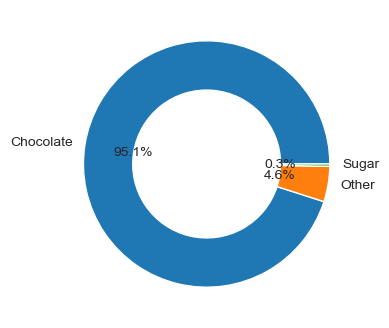

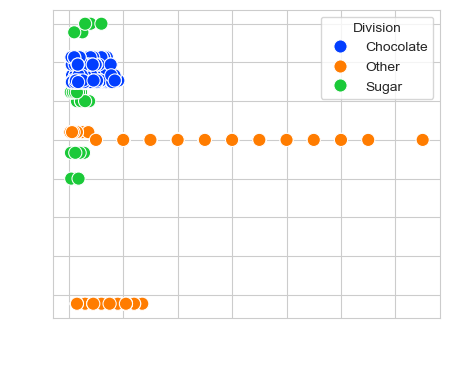

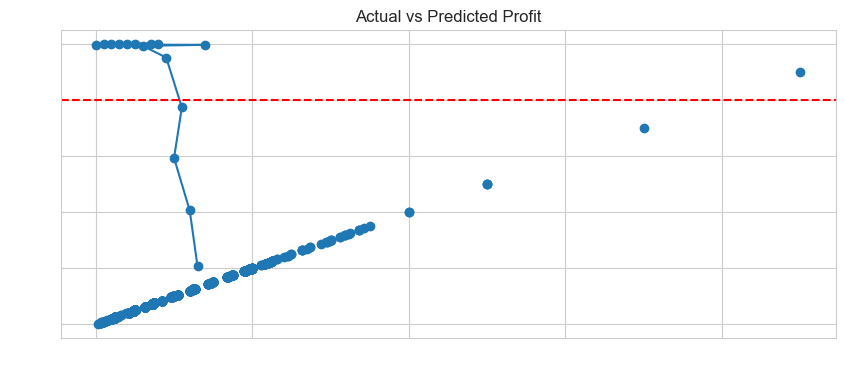

In [57]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Profit")

plt.ylabel("Predicted Profit")

plt.title("Actual vs Predicted Profit")

plt.show()